# Proyecto Deep Learning Spotify: Tarea 3 - Modelo 3: Regularización Con Dropout

## Configuración del entorno

In [ ]:
%pip install -r ../requirements.txt

In [14]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping


sys.path.append(os.path.abspath('..'))
from models.T3_M3_regularizacion_con_dropout import crear_modelo

In [15]:
df = pd.read_csv(r'..\data\data.csv')

df_limpio = df[
    (df['duration_ms'] > 40000) & 
    (df['speechiness'] < 0.90) & 
    (df['tempo'] > 0)
].copy()

cols_to_drop = ['popularity', 'id', 'name', 'artists', 'id_artists', 'release_date', 'mode']
X = df_limpio.drop(columns=cols_to_drop, errors='ignore')
y = df_limpio['popularity']

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [17]:
modelo_nn = crear_modelo(X_train_scaled.shape[1])

print("RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)")
modelo_nn.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 297.9805 - mae: 12.3702 - val_loss: 121.2844 - val_mae: 7.8103
Epoch 2/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 154.4676 - mae: 9.0362 - val_loss: 110.1081 - val_mae: 7.3615
Epoch 3/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 142.8349 - mae: 8.6492 - val_loss: 108.3354 - val_mae: 7.2740
Epoch 4/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 137.0977 - mae: 8.4656 - val_loss: 106.2314 - val_mae: 7.3350
Epoch 5/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 132.8256 - mae: 8.3321 - val_loss: 106.2879 - val_mae: 7.3346
Epoch 6/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 129.7436 - mae: 8.2366 - val_loss: 106.4593 - val_mae: 7.2566
Epoch 7/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 126.3395 - mae: 8.1128 - val_loss: 106.3974 - val_mae: 7.3203
Epoch 8/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 124.3201 - mae: 8.0554 - val_loss: 106.1479 - val_mae: 7.3105

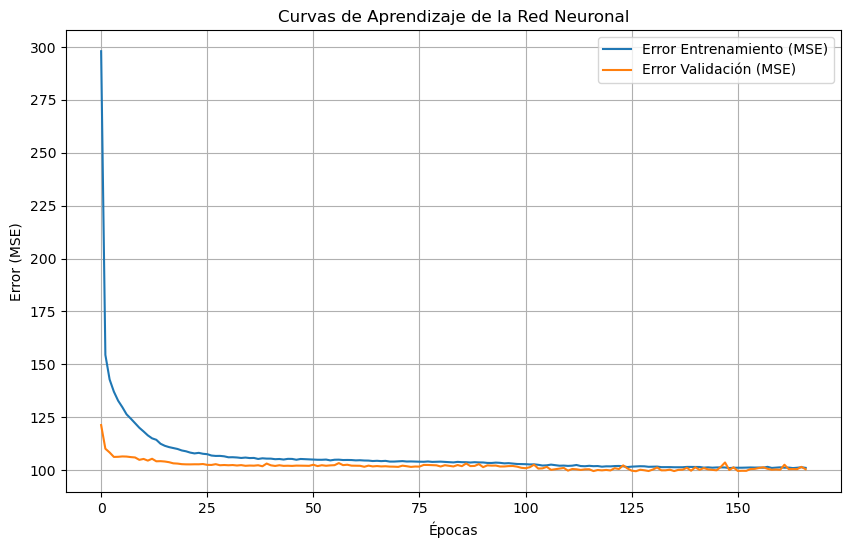

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(historia.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def evaluar_red(modelo, X_data, y_true, nombre_conjunto):
    y_pred = modelo.predict(X_data, verbose=0).flatten()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados en {nombre_conjunto} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print("EVALUACIÓN RED NEURONAL\n")

evaluar_red(modelo_nn, X_train_scaled, y_train, "ENTRENAMIENTO")
evaluar_red(modelo_nn, X_val_scaled, y_val, "VALIDACIÓN")
evaluar_red(modelo_nn, X_test_scaled, y_test, "TEST")

EVALUACIÓN RED NEURONAL

--- Resultados en ENTRENAMIENTO ---
MSE:  98.57
RMSE: 9.93
R²:   0.7882

--- Resultados en VALIDACIÓN ---
MSE:  99.47
RMSE: 9.97
R²:   0.7871

--- Resultados en TEST ---
MSE:  94.11
RMSE: 9.70
R²:   0.7957

